In [46]:
import pandas as pd
import numpy as np

In [47]:
import tensorflow as tf

In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

In [7]:
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [10]:
### Data Preprocessing ###

x_train=x_train.reshape(x_train.shape[0],28,28,1)
x_test=x_test.reshape(x_test.shape[0],28,28,1)

In [12]:
input_shape=(28,28,1)

In [17]:
x_train.dtype # output: dtype('uint8'): unsigned 8-bit integer that holds only non-negative integers from 0 to 255

dtype('uint8')

In [18]:
x_train=x_train.astype('float32')
x_test=x_test.astype('float32')

In [22]:
# Normalization: bringing the values within the range of 0 to 1

x_train/=255
x_test/=255

In [25]:
### Model Creation ###

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D

In [27]:
model=Sequential()
model.add(Conv2D(28,kernel_size=(3,3),input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

In [28]:
# Compilation and Fitting
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(x=x_train,y=y_train,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.2156 - accuracy: 0.9342
Epoch 2/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0858 - accuracy: 0.9736
Epoch 3/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0580 - accuracy: 0.9811
Epoch 4/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0435 - accuracy: 0.9852
Epoch 5/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0338 - accuracy: 0.9889
Epoch 6/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0291 - accuracy: 0.9904
Epoch 7/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0251 - accuracy: 0.9914
Epoch 8/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0199 - accuracy: 0.9934
Epoch 9/10
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0197 - accuracy: 0.9936
Epoch 10/10
1875/1875 [==============================] - 12s 6ms/step - l

In [29]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.0633 - accuracy: 0.9854


[0.06328378617763519, 0.9854000210762024]

PREDICTED VALUE IS:  6


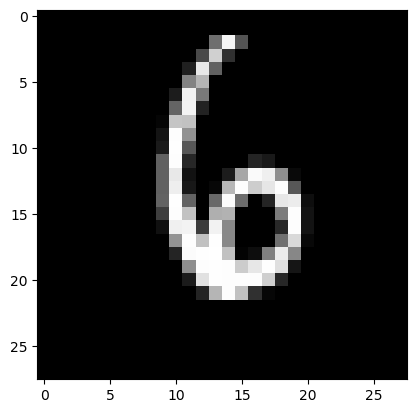

In [63]:
### Testing and Visualization ###

import matplotlib.pyplot as plt
image_index=6900
plt.imshow(x_test[image_index].reshape(28,28),cmap='gray')
pred=model.predict(x_test[image_index].reshape(1,28,28,1))
print("PREDICTED VALUE IS: ",pred.argmax())

In [52]:
### Confusion Matrix and Classification Report ###

from sklearn.metrics import confusion_matrix
y_pred=model.predict(x_test)
y_predict=np.argmax(y_pred,axis=1)
cm=confusion_matrix(y_test,y_predict)

In [53]:
cm

array([[ 971,    0,    1,    0,    0,    1,    5,    1,    1,    0],
       [   0, 1123,    1,    2,    0,    2,    5,    2,    0,    0],
       [   2,    1, 1007,    0,    2,    0,    3,   10,    5,    2],
       [   0,    0,    1,  992,    0,   11,    0,    3,    3,    0],
       [   0,    1,    0,    0,  965,    0,    6,    0,    1,    9],
       [   0,    0,    1,    2,    0,  886,    3,    0,    0,    0],
       [   2,    2,    0,    0,    1,    3,  949,    0,    1,    0],
       [   1,    1,    7,    0,    0,    0,    0, 1015,    2,    2],
       [   4,    0,    0,    1,    2,    7,    2,    4,  953,    1],
       [   1,    1,    0,    3,    5,    2,    1,    3,    0,  993]],
      dtype=int64)

In [61]:
np.argmax(y_pred,axis=1)

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [65]:
from sklearn.metrics import classification_report
cf=classification_report(y_test,y_predict)
print(cf)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.97      0.99      0.98       892
           6       0.97      0.99      0.98       958
           7       0.98      0.99      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

